# Steam Game Reviews
## Notebook 00 — Full-data preparation and quality checks

Local notebook · Apple Silicon-compatible

### Scope

Canonical data preparation. The downstream modelling notebooks read the
artifacts written here, so this notebook runs first.

It loads all 992,153 raw reviews, checks missingness and duplicate patterns,
detects language on every row, applies the cleaning sequence, repairs dates, joins
a primary genre, builds the model-input text, then draws the reproducible
120,000-review modelling sample and the game-grouped train/test split.

**Runtime.** Language detection over ~992k rows is the slow part, roughly 25-40
minutes on an M4 Pro. It is cached to `outputs/data/language_labels_full.parquet`,
so later runs skip it and finish in a couple of minutes. No GPU is used here.

**Environment.** Run in the `nlp` conda environment (conda-forge builds of torch
and faiss share one OpenMP runtime; pip wheels of both crash the kernel on macOS).

## Context & Methods

### 1. Configuration and paths

In [1]:
from pathlib import Path
import html
import json
import os
import re
import unicodedata
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import GroupShuffleSplit, StratifiedShuffleSplit

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)

SEED = 42
MODELLING_SAMPLE_SIZE = 120_000
# Leave a couple of cores free so the machine stays responsive.
# On Windows joblib spawns processes instead of forking, which is slower and can
# be flaky inside notebooks. Set LANGUAGE_JOBS = 1 there if the cell stalls; the
# language labels are cached to parquet, so the cost is paid only once.
LANGUAGE_JOBS = max(1, (os.cpu_count() or 4) - 2)

def find_project_dir(markers=("Data", "data", "outputs"), max_up=4):
    """Locate the project root by walking up from the working directory.

    Portable across macOS, Windows and Linux: no hard-coded absolute paths, and it
    works whether the notebook sits in the project root or in a subfolder.
    """
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents][: max_up + 1]:
        if any((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError(
        f"Could not locate the project root starting from {start}.\n"
        f"Expected a folder containing one of {markers}.\n"
        "Open the notebook from inside the project folder (the one holding Data/)."
    )

PROJECT_DIR = find_project_dir()

DATA_DIR = PROJECT_DIR / "Data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DATA = OUTPUT_DIR / "data"
OUTPUT_TABLES = OUTPUT_DIR / "tables"
OUTPUT_FIGURES = OUTPUT_DIR / "figures"
OUTPUT_SPLITS = OUTPUT_DIR / "splits"
for folder in [OUTPUT_DATA, OUTPUT_TABLES, OUTPUT_FIGURES, OUTPUT_SPLITS]:
    folder.mkdir(parents=True, exist_ok=True)

REVIEWS_PATH = DATA_DIR / "steam_game_reviews.csv"
RANKINGS_PATH = DATA_DIR / "games_ranking.csv"
LANGUAGE_CACHE = OUTPUT_DATA / "language_labels_full.parquet"
FULL_OUTPUT = OUTPUT_DATA / "prepared_reviews_full.parquet"
SAMPLE_OUTPUT = OUTPUT_DATA / "modelling_sample_120k.parquet"

for required in [REVIEWS_PATH, RANKINGS_PATH]:
    assert required.exists(), f"Missing raw file: {required}"

print("Project:", PROJECT_DIR)
print("Modelling sample target:", f"{MODELLING_SAMPLE_SIZE:,}")
print("Language detection workers:", LANGUAGE_JOBS)
print("Language cache present:", LANGUAGE_CACHE.exists())

Project: /Users/ioannis_tsantilas/Tsantil/Deree/MSc Data Science/ITC6110B1 - NATURAL LANGUAGE PROCESSING - SPRING TERM 2026/Group Project
Modelling sample target: 120,000
Language detection workers: 12
Language cache present: True


### 2. Load all review rows

In [2]:
usecols = [
    "review", "hours_played", "helpful", "funny",
    "recommendation", "date", "game_name", "username",
]
reviews_raw = pd.read_csv(REVIEWS_PATH, usecols=usecols, low_memory=False)
reviews_raw.insert(0, "raw_row_id", np.arange(len(reviews_raw), dtype=np.int64))

print("Raw shape:", reviews_raw.shape)
print("Games:", reviews_raw["game_name"].nunique())
display(reviews_raw.head(3))

Raw shape: (992153, 9)
Games: 242


,raw_row_id,review,hours_played,helpful,funny,recommendation,date,game_name,username
0,0,The game itself is also super fun. The PvP and...,39.9,"1,152",13,Recommended,14 September,"Warhammer 40,000: Space Marine 2",Sentinowl\n224 products in account
1,1,Never cared much about Warhammer until this ga...,91.5,712,116,Recommended,13 September,"Warhammer 40,000: Space Marine 2",userpig\n248 products in account
2,2,A salute to all the fallen battle brothers who...,43.3,492,33,Recommended,14 September,"Warhammer 40,000: Space Marine 2",Imparat0r\n112 products in account


### 3. Check grain, missingness and duplicate patterns

In [3]:
missing = reviews_raw.drop(columns="raw_row_id").isna().sum().rename("missing_rows").to_frame()
missing["missing_percent"] = 100 * missing["missing_rows"] / len(reviews_raw)

exact_duplicate_rows = reviews_raw.drop(columns="raw_row_id").duplicated().sum()
duplicate_review_beyond_first = reviews_raw.duplicated(["review"], keep="first").sum()
duplicate_within_game_beyond_first = reviews_raw.duplicated(["game_name", "review"], keep="first").sum()
duplicate_same_user_game_text = reviews_raw.duplicated(
    ["game_name", "username", "review"], keep="first"
).sum()

display(missing)
print("Exact duplicate rows:", f"{exact_duplicate_rows:,}")
print("Repeated review text beyond first row:", f"{duplicate_review_beyond_first:,}")
print("Repeated game + review beyond first row:", f"{duplicate_within_game_beyond_first:,}")
print("Repeated game + username + review beyond first row:", f"{duplicate_same_user_game_text:,}")

# Only exact duplicated rows are removed. Generic repeated phrases from different users are valid observations.
exact_mask = reviews_raw.drop(columns="raw_row_id").duplicated(keep="first")
reviews = reviews_raw.loc[~exact_mask].copy()
reviews = reviews.dropna(subset=["review", "game_name", "recommendation"]).copy()
reviews["review"] = reviews["review"].astype(str).str.strip()
reviews = reviews.loc[reviews["review"].ne("")].copy()
reviews["target"] = reviews["recommendation"].map({"Not Recommended": 0, "Recommended": 1})
reviews = reviews.dropna(subset=["target"]).copy()
reviews["target"] = reviews["target"].astype("int8")

print("Rows after exact duplicates and unusable text/labels:", f"{len(reviews):,}")

,missing_rows,missing_percent
review,503,0.050698
hours_played,0,0.000000
helpful,0,0.000000
funny,0,0.000000
recommendation,0,0.000000
date,0,0.000000
game_name,0,0.000000
username,81,0.008164


Exact duplicate rows: 1
Repeated review text beyond first row: 82,416
Repeated game + review beyond first row: 31,243
Repeated game + username + review beyond first row: 3
Rows after exact duplicates and unusable text/labels: 991,649


### 4. Detect review language (full dataset)

In [4]:
from langdetect import DetectorFactory, LangDetectException, detect

DetectorFactory.seed = SEED

def detect_language(text):
    # Setting the seed inside each worker makes process-level results repeatable.
    DetectorFactory.seed = SEED
    try:
        return detect(str(text))
    except LangDetectException:
        return "unknown"

cache_is_usable = False
if LANGUAGE_CACHE.exists():
    language_cache = pd.read_parquet(LANGUAGE_CACHE)
    cache_is_usable = (
        len(language_cache) == len(reviews_raw)
        and language_cache["raw_row_id"].iloc[0] == 0
        and language_cache["raw_row_id"].iloc[-1] == len(reviews_raw) - 1
    )

if cache_is_usable:
    print("Using cached language labels:", LANGUAGE_CACHE)
else:
    print("Detecting language for all raw rows. First run takes several minutes...")
    language_values = joblib.Parallel(n_jobs=LANGUAGE_JOBS, batch_size=256, verbose=5)(
        joblib.delayed(detect_language)(text) for text in reviews_raw["review"]
    )
    language_cache = pd.DataFrame({
        "raw_row_id": reviews_raw["raw_row_id"].to_numpy(),
        "language": language_values,
    })
    language_cache.to_parquet(LANGUAGE_CACHE, index=False)
    print("Saved language cache:", LANGUAGE_CACHE)

reviews = reviews.merge(language_cache, on="raw_row_id", how="left", validate="one_to_one")
language_summary = reviews["language"].value_counts(dropna=False).rename_axis("language").reset_index(name="reviews")
language_summary["percent"] = 100 * language_summary["reviews"] / len(reviews)
language_summary.to_csv(OUTPUT_TABLES / "full_language_distribution.csv", index=False)
display(language_summary.head(15))

english_reviews = reviews.loc[reviews["language"].eq("en")].copy()
print("English reviews retained:", f"{len(english_reviews):,}", f"({len(english_reviews)/len(reviews):.1%})")

Using cached language labels: /Users/ioannis_tsantilas/Tsantil/Deree/MSc Data Science/ITC6110B1 - NATURAL LANGUAGE PROCESSING - SPRING TERM 2026/Group Project/outputs/data/language_labels_full.parquet


,language,reviews,percent
0,en,843914,85.102088
1,so,17979,1.813041
2,unknown,13409,1.352192
3,de,9758,0.984018
4,af,9476,0.955580
5,tl,7186,0.724652
6,cy,6839,0.689659
7,no,6580,0.663541
8,tr,6494,0.654869
9,es,6243,0.629557


English reviews retained: 843,914 (85.1%)


### 5. Clean text using the lecture-style preprocessing sequence

In [5]:
NEGATIONS = {"no", "nor", "not", "never", "cannot"}
STOP_WORDS = set(ENGLISH_STOP_WORDS) - NEGATIONS

URL_RE = re.compile(r"https?://\S+|www\.\S+", flags=re.I)
USER_RE = re.compile(r"@[A-Za-z0-9_]+")
HTML_RE = re.compile(r"<[^>]+>")
NON_LETTER_RE = re.compile(r"[^a-z'\s]")
REPEATED_RE = re.compile(r"(.)\1{2,}")
SPACE_RE = re.compile(r"\s+")

def preprocess_text(text):
    text = html.unescape(str(text)).lower()
    text = URL_RE.sub(" url ", text)
    text = USER_RE.sub(" user ", text)
    text = HTML_RE.sub(" ", text)
    text = REPEATED_RE.sub(r"\1\1", text)
    text = NON_LETTER_RE.sub(" ", text)
    tokens = [
        token for token in SPACE_RE.split(text.strip())
        if token and (len(token) >= 2 or token in NEGATIONS) and token not in STOP_WORDS
    ]
    return " ".join(tokens)

english_reviews["word_count"] = english_reviews["review"].str.split().str.len().astype("int32")
english_reviews["clean_review"] = english_reviews["review"].map(preprocess_text)
english_reviews = english_reviews.loc[english_reviews["clean_review"].str.len().gt(0)].copy()

display(english_reviews[["review", "clean_review"]].sample(5, random_state=SEED))
print("Rows with non-empty cleaned text:", f"{len(english_reviews):,}")

,review,clean_review
515770,2023 i drive for 5km and my truck go on side (...,drive km truck sadface
211094,2021 Early Access Review This game is like a N...,early access review game like new zealand coun...
447906,Waiter waiter more Mili music please,waiter waiter mili music
113999,10 years later and bungie STILL can't have sta...,years later bungie can't stable servers
344785,"2020 Fantastic sequel, that gets everything ri...",fantastic sequel gets right improves areas pre...


Rows with non-empty cleaned text: 843,094


### 6. Repair dates and label imputed years

In [6]:
date_text = english_reviews["date"].astype(str).str.strip()
english_reviews["year_imputed"] = ~date_text.str.contains(r"\b(?:19|20)\d{2}\b", regex=True, na=False)
date_with_year = date_text.where(~english_reviews["year_imputed"], date_text + ", 2024")
english_reviews["review_date"] = pd.to_datetime(date_with_year, errors="coerce", format="mixed")
english_reviews["review_year"] = english_reviews["review_date"].dt.year.astype("Int16")

print("Explicit year:", f"{(~english_reviews['year_imputed']).mean():.1%}")
print("Parse success:", f"{english_reviews['review_date'].notna().mean():.1%}")
print("Date range:", english_reviews["review_date"].min(), "to", english_reviews["review_date"].max())

Explicit year: 77.2%
Parse success: 100.0%
Date range: 2010-10-16 00:00:00 to 2024-09-23 00:00:00


### 7. Join a reproducible primary broad genre

In [7]:
def normalize_title(value):
    value = unicodedata.normalize("NFKD", str(value))
    value = value.replace("®", "").replace("™", "").replace("©", "")
    value = value.lower().replace("&", " and ")
    value = re.sub(r"[^a-z0-9]+", " ", value)
    return re.sub(r"\s+", " ", value).strip()

rankings = pd.read_csv(RANKINGS_PATH)
rankings["title_key"] = rankings["game_name"].map(normalize_title)

# A game can occur in more than one broad genre. Use the genre with its best rank as a single plotting label.
primary_genre = (
    rankings.sort_values(["rank", "genre", "rank_type"])
    .drop_duplicates("title_key", keep="first")
    [["title_key", "genre"]]
    .rename(columns={"genre": "primary_genre"})
)
english_reviews["title_key"] = english_reviews["game_name"].map(normalize_title)
english_reviews = english_reviews.merge(primary_genre, on="title_key", how="left", validate="many_to_one")

genre_coverage = english_reviews["primary_genre"].notna().mean()
print("Primary-genre join coverage:", f"{genre_coverage:.1%}")
display(english_reviews["primary_genre"].value_counts(dropna=False).to_frame("reviews"))

Primary-genre join coverage: 93.2%


,reviews
primary_genre,
Strategy,200091
Simulation,161622
Sports & Racing,120945
Action,110821
Role-Playing,102788
Adventure,89440
NaN,57387


### 8. Build the model-input text

The transformer reads near-raw text, but a leading bare year such as
`2020 great game` is a date artifact rather than review content. The earlier SHAP
audit showed the classifier picking those year tokens up as spurious predictors,
so a *leading* year only is stripped and everything else is left intact.

Producing `model_text` here rather than downstream means every notebook inherits
the same corrected input, instead of the classifier depending on the embeddings
notebook for its text.

In [8]:
LEADING_YEAR_RE = r"^\s*(?:19|20)\d{2}\b[\s,:;\-–—]*"

english_reviews["model_text"] = english_reviews["review"].str.replace(
    LEADING_YEAR_RE, "", regex=True
)
# Never let the strip empty a review; fall back to the original text.
english_reviews["model_text"] = english_reviews["model_text"].where(
    english_reviews["model_text"].str.strip().str.len().gt(0),
    english_reviews["review"],
)

stripped = english_reviews["model_text"].ne(english_reviews["review"]).sum()
print("Reviews with a leading year removed:", f"{stripped:,}",
      f"({stripped/len(english_reviews):.2%})")
display(
    english_reviews.loc[
        english_reviews["model_text"].ne(english_reviews["review"]),
        ["review", "model_text"],
    ].head(5)
)

Reviews with a leading year removed: 650,692 (77.18%)


,review,model_text
1228,2024 triple A game and no ultrawide support.Th...,triple A game and no ultrawide support.This ga...
2380,"2024 año del señor, Should be illegal to launc...","año del señor, Should be illegal to launch a g..."
3231,2024 - The year of monke.A really excellent so...,The year of monke.A really excellent souls-lik...
3759,2024 Game of The Year,Game of The Year
5326,2023 - fix random cash issues- add new skins- ...,fix random cash issues- add new skins- add mor...


## Results

### 8. Export the canonical full English table

In [9]:
keep_columns = [
    "raw_row_id", "game_name", "recommendation", "target", "review", "clean_review",
    "model_text", "word_count", "hours_played", "helpful", "funny", "date",
    "review_date", "review_year", "year_imputed", "language", "primary_genre", "username",
]
prepared_full = english_reviews[keep_columns].reset_index(drop=True)
prepared_full.to_parquet(FULL_OUTPUT, index=False, compression="zstd")

print("Saved:", FULL_OUTPUT)
print("Final full English shape:", prepared_full.shape)
print("File size (MB):", round(FULL_OUTPUT.stat().st_size / 1024**2, 1))

Saved: /Users/ioannis_tsantilas/Tsantil/Deree/MSc Data Science/ITC6110B1 - NATURAL LANGUAGE PROCESSING - SPRING TERM 2026/Group Project/outputs/data/prepared_reviews_full.parquet
Final full English shape: (843094, 18)
File size (MB): 395.7


### 9. Draw the reproducible modelling sample and split by game

In [10]:
# Stratify by game so all 242 titles remain represented. One game has only one
# English negative review, so exact game-by-label stratification is not mathematically possible.
strata = prepared_full["game_name"].astype(str)
sample_splitter = StratifiedShuffleSplit(n_splits=1, train_size=MODELLING_SAMPLE_SIZE, random_state=SEED)
sample_indices, _ = next(sample_splitter.split(np.zeros(len(prepared_full)), strata))
model_sample = prepared_full.iloc[np.sort(sample_indices)].reset_index(drop=True)

group_splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(group_splitter.split(model_sample, model_sample["target"], groups=model_sample["game_name"]))

train_games = set(model_sample.loc[train_idx, "game_name"])
test_games = set(model_sample.loc[test_idx, "game_name"])

model_sample.to_parquet(SAMPLE_OUTPUT, index=False, compression="zstd")
np.save(OUTPUT_SPLITS / "train_idx.npy", train_idx)
np.save(OUTPUT_SPLITS / "test_idx.npy", test_idx)
pd.DataFrame({"game_name": sorted(test_games)}).to_csv(OUTPUT_SPLITS / "test_games.csv", index=False)

sample_summary = pd.DataFrame([
    {"split": "full English", "reviews": len(prepared_full), "games": prepared_full["game_name"].nunique(), "recommended_share": prepared_full["target"].mean()},
    {"split": "modelling sample", "reviews": len(model_sample), "games": model_sample["game_name"].nunique(), "recommended_share": model_sample["target"].mean()},
    {"split": "train", "reviews": len(train_idx), "games": len(train_games), "recommended_share": model_sample.loc[train_idx, "target"].mean()},
    {"split": "test", "reviews": len(test_idx), "games": len(test_games), "recommended_share": model_sample.loc[test_idx, "target"].mean()},
])
sample_summary.to_csv(OUTPUT_TABLES / "full_data_and_sample_summary.csv", index=False)
display(sample_summary.style.format({"recommended_share": "{:.1%}"}))
print("Train/test game overlap:", len(train_games & test_games))
print("Saved modelling sample:", SAMPLE_OUTPUT)

,split,reviews,games,recommended_share
0,full English,843094,242,79.4%
1,modelling sample,120000,242,79.6%
2,train,95658,193,79.2%
3,test,24342,49,81.3%


Train/test game overlap: 0
Saved modelling sample: /Users/ioannis_tsantilas/Tsantil/Deree/MSc Data Science/ITC6110B1 - NATURAL LANGUAGE PROCESSING - SPRING TERM 2026/Group Project/outputs/data/modelling_sample_120k.parquet


### 10. Save compact quality evidence

In [11]:
quality_rows = [
    ("raw_rows", len(reviews_raw), 1.0, "Reference row count"),
    ("missing_review", reviews_raw["review"].isna().sum(), reviews_raw["review"].isna().mean(), "Removed before modelling"),
    ("missing_username", reviews_raw["username"].isna().sum(), reviews_raw["username"].isna().mean(), "Username is not a model feature"),
    ("exact_duplicate_rows", exact_duplicate_rows, exact_duplicate_rows / len(reviews_raw), "One copy retained"),
    ("repeated_review_text_beyond_first", duplicate_review_beyond_first, duplicate_review_beyond_first / len(reviews_raw), "Not removed automatically; many are valid generic phrases"),
    ("english_rows_after_basic_validity", len(prepared_full), len(prepared_full) / len(reviews_raw), "Canonical analysis population"),
    ("date_year_imputed", prepared_full["year_imputed"].sum(), prepared_full["year_imputed"].mean(), "2024 assumed; not used as intended classifier input"),
    ("unparsed_review_date", prepared_full["review_date"].isna().sum(), prepared_full["review_date"].isna().mean(), "Excluded only from time figures"),
    ("missing_primary_genre", prepared_full["primary_genre"].isna().sum(), prepared_full["primary_genre"].isna().mean(), "Kept for non-genre analyses"),
]
quality_summary = pd.DataFrame(quality_rows, columns=["check", "count", "rate", "treatment_or_risk"])
quality_summary.to_csv(OUTPUT_TABLES / "full_data_quality_summary.csv", index=False)
display(quality_summary.style.format({"rate": "{:.2%}"}))

,check,count,rate,treatment_or_risk
0,raw_rows,992153,100.00%,Reference row count
1,missing_review,503,0.05%,Removed before modelling
2,missing_username,81,0.01%,Username is not a model feature
3,exact_duplicate_rows,1,0.00%,One copy retained
4,repeated_review_text_beyond_first,82416,8.31%,Not removed automatically; many are valid generic phrases
5,english_rows_after_basic_validity,843094,84.98%,Canonical analysis population
6,date_year_imputed,192431,22.82%,2024 assumed; not used as intended classifier input
7,unparsed_review_date,0,0.00%,Excluded only from time figures
8,missing_primary_genre,57387,6.81%,Kept for non-genre analyses


### 11. Full-data figures

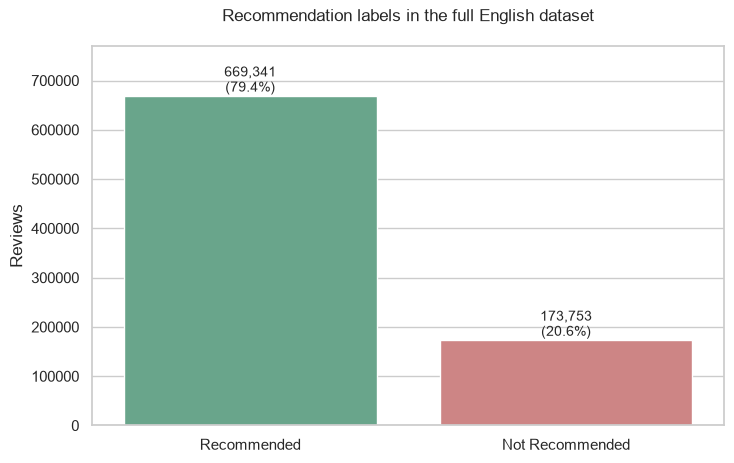

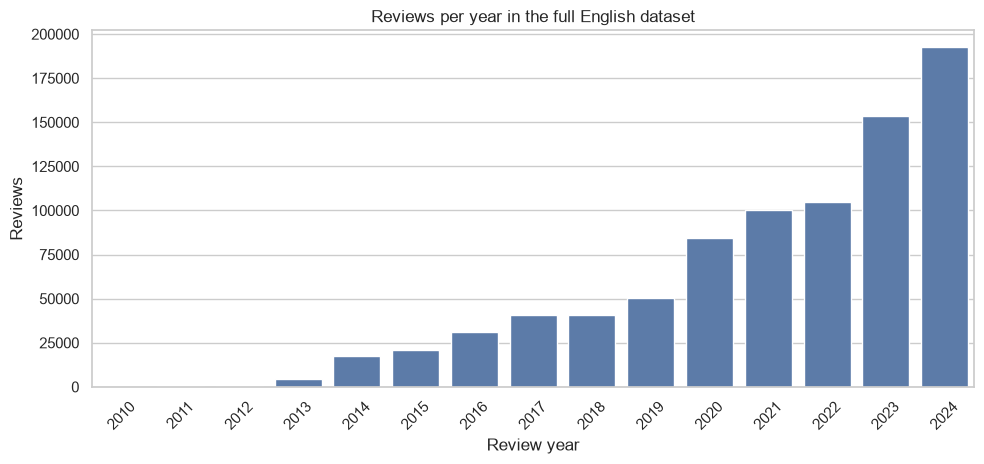

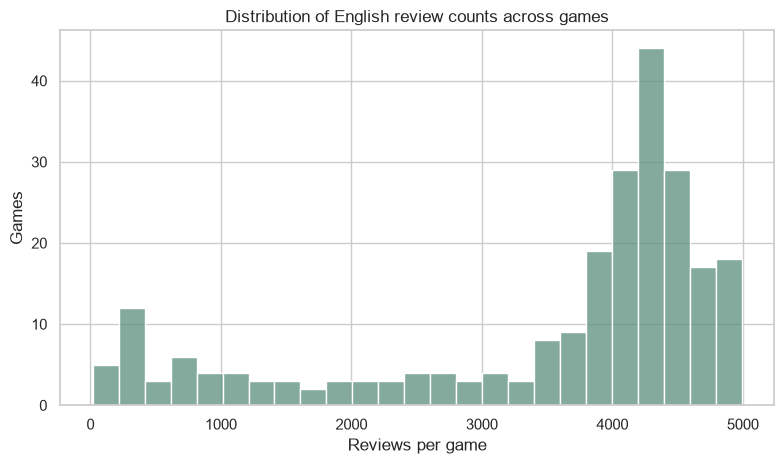

In [12]:
sns.set_theme(style="whitegrid", context="notebook")

label_counts = prepared_full["recommendation"].value_counts().reindex(["Recommended", "Not Recommended"])
fig, ax = plt.subplots(figsize=(7.5, 4.8))
sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, palette=["#5FAF8C", "#D97979"], legend=False, ax=ax)
ax.set(title="Recommendation labels in the full English dataset", xlabel="", ylabel="Reviews")
ax.set_title("Recommendation labels in the full English dataset", pad=18)
ax.set_ylim(0, label_counts.max() * 1.15)
ax.ticklabel_format(style="plain", axis="y")
for i, value in enumerate(label_counts.values):
    ax.text(i, value, f"{value:,}\n({value/label_counts.sum():.1%})", ha="center", va="bottom", fontsize=10)
fig.tight_layout()
fig.savefig(OUTPUT_FIGURES / "full_class_balance.png", dpi=180, bbox_inches="tight")
plt.show()

year_counts = prepared_full.loc[prepared_full["review_date"].notna()].groupby("review_year").size()
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.barplot(x=year_counts.index.astype(str), y=year_counts.values, color="#4F79B5", ax=ax)
ax.set(title="Reviews per year in the full English dataset", xlabel="Review year", ylabel="Reviews")
ax.tick_params(axis="x", rotation=45)
ax.ticklabel_format(style="plain", axis="y")
fig.tight_layout()
fig.savefig(OUTPUT_FIGURES / "full_reviews_per_year.png", dpi=180, bbox_inches="tight")
plt.show()

game_counts = prepared_full["game_name"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.histplot(game_counts, bins=25, color="#5B8E7D", ax=ax)
ax.set(title="Distribution of English review counts across games", xlabel="Reviews per game", ylabel="Games")
fig.tight_layout()
fig.savefig(OUTPUT_FIGURES / "full_reviews_per_game.png", dpi=180, bbox_inches="tight")
plt.show()

## Takeaways

In [13]:
print(f"The raw file contains {len(reviews_raw):,} rows across {reviews_raw['game_name'].nunique()} games.")
print(f"After validity checks, English filtering and non-empty cleaning, {len(prepared_full):,} reviews remain.")
print(f"Recommended reviews make up {prepared_full['target'].mean():.1%} of the canonical population.")
print(f"The modelling sample contains {len(model_sample):,} reviews and all {model_sample['game_name'].nunique()} games.")
print(f"The grouped split has {len(train_idx):,} train and {len(test_idx):,} test reviews, with no shared games.")
print("Main caveats: language detection is uncertain for very short reviews, dates without years are imputed, and the primary genre is a simplified label.")

The raw file contains 992,153 rows across 242 games.
After validity checks, English filtering and non-empty cleaning, 843,094 reviews remain.
Recommended reviews make up 79.4% of the canonical population.
The modelling sample contains 120,000 reviews and all 242 games.
The grouped split has 95,658 train and 24,342 test reviews, with no shared games.
Main caveats: language detection is uncertain for very short reviews, dates without years are imputed, and the primary genre is a simplified label.


## Checks

In [14]:
assert len(reviews_raw) == 992_153
assert reviews_raw["game_name"].nunique() == 242
assert prepared_full["raw_row_id"].is_unique
assert prepared_full["review"].notna().all()
assert prepared_full["clean_review"].str.len().gt(0).all()
assert prepared_full["model_text"].str.len().gt(0).all()
assert prepared_full["language"].eq("en").all()
assert prepared_full["target"].isin([0, 1]).all()
assert len(model_sample) == MODELLING_SAMPLE_SIZE
assert model_sample["game_name"].nunique() == 242
assert "model_text" in model_sample.columns
assert len(set(train_idx) & set(test_idx)) == 0
assert len(train_games & test_games) == 0
assert len(train_idx) + len(test_idx) == len(model_sample)
assert (OUTPUT_SPLITS / "test_games.csv").exists()
print("All canonical-data and split checks passed.")

All canonical-data and split checks passed.


## Artifacts

| File | Purpose | Read by |
|---|---|---|
| `outputs/data/language_labels_full.parquet` | cached language label per raw row | this notebook on reruns |
| `outputs/data/prepared_reviews_full.parquet` | full cleaned English population (~843k) | full-corpus figures, notebook 06 |
| `outputs/data/modelling_sample_120k.parquet` | the 120k modelling sample | notebooks 01-05 |
| `outputs/splits/train_idx.npy`, `test_idx.npy` | game-grouped split indices | notebooks 03, 04 |
| `outputs/splits/test_games.csv` | held-out game names | report |
| `outputs/tables/*.csv` | quality, language and sample summaries | report |
| `outputs/figures/full_*.png` | full-corpus figures | report, slides |

**Next:** notebook 03, which reads `modelling_sample_120k.parquet` and the split
indices.